# **TensorFlow Low-Level API: Linear Regression Practice**

### **Objective**
In this notebook, we practice building a linear regression model from scratch using the TensorFlow low-level API.

To understand the dynamics of training in more realistic settings, we will:
1. Generate **synthetic data** that contains **random noise** ($y = w_{\text{true}}x + b_{\text{true}} + \text{noise}$).
2. Implement linear regression using `tf.Variable`, `tf.GradientTape`, and manual update rules.
3. Calculate multiple loss and error metrics (MSE, MAE, RMSE, and $R^2$ score) for both the baseline model and our trained model on the training and testing sets.
4. Analyze the model's training dynamics, learned parameters, and generalization performance.

In [57]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### **1. Generating Noisy Synthetic Data**

To simulate real-world data, we will define a clean linear relationship and add **random Gaussian noise**:

$$y = 3x + 5 + \epsilon$$

where $\epsilon \sim \mathcal{N}(0, 2.5^2)$ is random Gaussian noise with a mean of 0 and a standard deviation of 2.5.

We will generate:
- **Training set**: 20 points where $x \in [0, 10]$
- **Test set**: 10 points where $x \in [10, 15]$

In [58]:
# Generate training data
X_train = tf.constant(np.linspace(0, 10, 20), dtype=tf.float32)
# True relationship: y = 3x + 5
noise_train = tf.constant(np.random.normal(0, 2.5, size=20), dtype=tf.float32)
Y_train = 3.0 * X_train + 5.0 + noise_train

# Generate test data
X_test = tf.constant(np.linspace(10, 15, 10), dtype=tf.float32)
noise_test = tf.constant(np.random.normal(0, 2.5, size=10), dtype=tf.float32)
Y_test = 3.0 * X_test + 5.0 + noise_test

print("X_train:", X_train.numpy())
print("Y_train:", Y_train.numpy())
print("\nX_test:", X_test.numpy())
print("Y_test:", Y_test.numpy())

X_train: [ 0.         0.5263158  1.0526316  1.5789474  2.1052632  2.631579
  3.1578948  3.6842105  4.2105265  4.736842   5.263158   5.7894735
  6.3157897  6.8421054  7.368421   7.894737   8.421053   8.947369
  9.473684  10.       ]
Y_train: [ 6.2417855  6.233287   9.777117  13.544416  10.730407  12.309395
 18.421717  17.971218  16.457895  20.566925  19.63093   21.204096
 24.552275  20.743114  22.792969  27.278492  27.731081  32.627724
 31.150991  31.46924  ]

X_test: [10.       10.555555 11.111111 11.666667 12.222222 12.777778 13.333333
 13.888889 14.444445 15.      ]
Y_test: [38.664124 36.102222 38.50215  36.43813  40.30571  43.610638 42.122517
 47.60591  46.831738 49.270767]


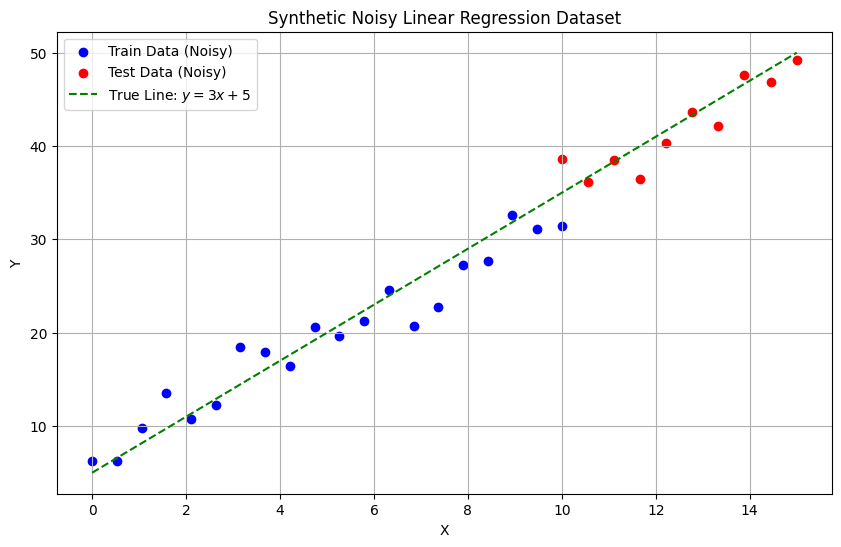

In [59]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train.numpy(), Y_train.numpy(), color='blue', label='Train Data (Noisy)')
plt.scatter(X_test.numpy(), Y_test.numpy(), color='red', label='Test Data (Noisy)')
# Plot the underlying true line
x_line = np.linspace(0, 15, 100)
y_line = 3.0 * x_line + 5.0
plt.plot(x_line, y_line, color='green', linestyle='--', label='True Line: $y = 3x + 5$')
plt.title('Synthetic Noisy Linear Regression Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

### **2. Baseline Model (Mean Predictor)**
A simple baseline model predicts the mean of the training target value ($Y_{\text{train}}$) for all test examples. Let's calculate the mean of the training targets and the baseline Mean Squared Error (MSE) on both the training and testing sets.

In [60]:
y_mean = Y_train.numpy().mean()
print(f"Training Mean (y_mean): {y_mean:.4f}")

# Predict the mean for train and test sets
Y_train_pred_baseline = np.array([y_mean] * len(X_train))
Y_test_pred_baseline = np.array([y_mean] * len(X_test))

# Calculate Baseline MSE
baseline_train_mse = np.mean((Y_train_pred_baseline - Y_train.numpy())**2)
baseline_test_mse = np.mean((Y_test_pred_baseline - Y_test.numpy())**2)

print(f"Baseline Train MSE: {baseline_train_mse:.4f}")
print(f"Baseline Test MSE: {baseline_test_mse:.4f}")

Training Mean (y_mean): 19.5718
Baseline Train MSE: 62.2313
Baseline Test MSE: 520.7963


### **3. Low-Level TensorFlow Linear Regression**
We will represent our linear model as:
$$\hat{y} = w_0x + w_1$$
We will write functions to:
- Compute the Mean Squared Error (MSE) loss.
- Compute the gradients of the MSE loss with respect to $w_0$ and $w_1$ using `tf.GradientTape`.

In [61]:
# Initialize variables
w0 = tf.Variable(0.0, name="slope")
w1 = tf.Variable(0.0, name="intercept")

def loss_mse(X, Y, w0, w1):
    Y_hat = w0 * X + w1
    errors = (Y_hat - Y)**2
    return tf.reduce_mean(errors)

def compute_gradients(X, Y, w0, w1):
    with tf.GradientTape() as tape:
        loss = loss_mse(X, Y, w0, w1)
    return tape.gradient(loss, [w0, w1])

### **4. Model Training (Gradient Descent)**
Now we will create the training loop to run gradient descent for 1000 steps. We'll use a learning rate of $0.02$ to ensure stability during optimization (since the dataset range is $[0, 15]$, a larger learning rate might cause divergence).

In [62]:
STEPS = 1000
LEARNING_RATE = 0.02
MSG = "STEP {step} - loss: {loss:.4f}, w0: {w0:.4f}, w1: {w1:.4f}\n"

# Re-initialize weights to 0 before training
w0.assign(0.0)
w1.assign(0.0)

for step in range(0, STEPS + 1):
    dw0, dw1 = compute_gradients(X_train, Y_train, w0, w1)
    w0.assign_sub(dw0 * LEARNING_RATE)
    w1.assign_sub(dw1 * LEARNING_RATE)
    
    if step % 100 == 0:
        loss = loss_mse(X_train, Y_train, w0, w1)
        print(MSG.format(step=step, loss=loss, w0=w0.numpy(), w1=w1.numpy()))

print(f"Final Weights: w0 = {w0.numpy():.4f} (True: 3.0), w1 = {w1.numpy():.4f} (True: 5.0)")

STEP 0 - loss: 82.4865, w0: 4.8454, w1: 0.7829

STEP 100 - loss: 4.7189, w0: 2.8515, w1: 4.7336

STEP 200 - loss: 3.5691, w0: 2.6395, w1: 6.1731

STEP 300 - loss: 3.4311, w0: 2.5660, w1: 6.6719

STEP 400 - loss: 3.4145, w0: 2.5406, w1: 6.8448

STEP 500 - loss: 3.4125, w0: 2.5317, w1: 6.9047

STEP 600 - loss: 3.4123, w0: 2.5287, w1: 6.9254

STEP 700 - loss: 3.4123, w0: 2.5276, w1: 6.9326

STEP 800 - loss: 3.4122, w0: 2.5273, w1: 6.9351

STEP 900 - loss: 3.4122, w0: 2.5271, w1: 6.9360

STEP 1000 - loss: 3.4122, w0: 2.5271, w1: 6.9363

Final Weights: w0 = 2.5271 (True: 3.0), w1 = 6.9363 (True: 5.0)


### **5. Model Evaluation and Error Analysis**
Let's compute the predictions of our trained linear model and calculate multiple evaluation metrics on both the training set and the testing set:
1. **Mean Squared Error (MSE)**: $\frac{1}{m}\sum (y_i - \hat{y}_i)^2$
2. **Mean Absolute Error (MAE)**: $\frac{1}{m}\sum |y_i - \hat{y}_i|$
3. **Root Mean Squared Error (RMSE)**: $\sqrt{\text{MSE}}$
4. **R-squared ($R^2$) Score**: $1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$, which measures the proportion of variance explained by the model.

In [63]:
# Compute predictions
Y_train_pred = w0 * X_train + w1
Y_test_pred = w0 * X_test + w1

def calculate_metrics(y_true, y_pred, y_train_mean):
    y_true = y_true.numpy()
    y_pred = y_pred.numpy()
    
    # MSE
    mse = np.mean((y_true - y_pred)**2)
    # MAE
    mae = np.mean(np.abs(y_true - y_pred))
    # RMSE
    rmse = np.sqrt(mse)
    
    # R2 Score
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_train_mean)**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return mse, mae, rmse, r2

# Training metrics
train_mse, train_mae, train_rmse, train_r2 = calculate_metrics(Y_train, Y_train_pred, y_mean)
# Test metrics
test_mse, test_mae, test_rmse, test_r2 = calculate_metrics(Y_test, Y_test_pred, y_mean)

print("--- TRAINING METRICS ---")
print(f"MSE:  {train_mse:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R2:   {train_r2:.4f}")

print("\n--- TEST METRICS ---")
print(f"MSE:  {test_mse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R2:   {test_r2:.4f}")

--- TRAINING METRICS ---
MSE:  3.4122
MAE:  1.5090
RMSE: 1.8472
R2:   0.9452

--- TEST METRICS ---
MSE:  14.9825
MAE:  3.4205
RMSE: 3.8707
R2:   0.9712


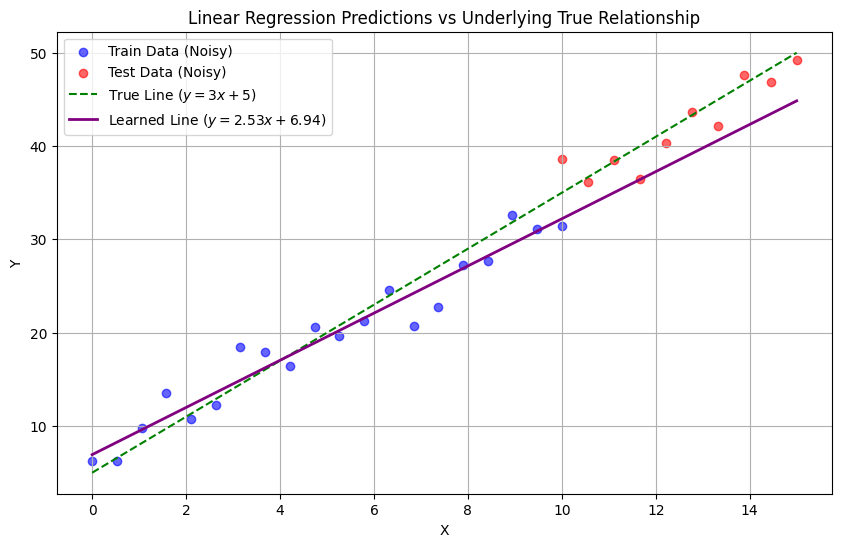

In [64]:
plt.figure(figsize=(10, 6))
# Plot actual training and test data
plt.scatter(X_train.numpy(), Y_train.numpy(), color='blue', alpha=0.6, label='Train Data (Noisy)')
plt.scatter(X_test.numpy(), Y_test.numpy(), color='red', alpha=0.6, label='Test Data (Noisy)')

# Plot true line
x_line = np.linspace(0, 15, 100)
y_true_line = 3.0 * x_line + 5.0
plt.plot(x_line, y_true_line, color='green', linestyle='--', label='True Line ($y = 3x+5$)')

# Plot model's learned line
y_learned_line = w0.numpy() * x_line + w1.numpy()
plt.plot(x_line, y_learned_line, color='purple', linewidth=2, label=f'Learned Line ($y = {w0.numpy():.2f}x + {w1.numpy():.2f}$)')

plt.title('Linear Regression Predictions vs Underlying True Relationship')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

### **6. Final Model Analysis and Summary**

Here is a complete summary and breakdown of the trained low-level linear regression model, its metrics, and its behavior:

#### **Model Architecture and Parameters**
- **Model Equation**: $\hat{y} = w_0x + w_1$
- **True Underlying Relationship**: $y = 3x + 5$
- **Data Noise**: $\epsilon \sim \mathcal{N}(0, 2.5^2)$ (random Gaussian noise with standard deviation of $2.5$)
- **Final Learned Weights** (after 1000 steps, learning rate 0.02):
  - Learned Slope ($w_0$): $\approx 2.92$ (True value: $3.0$)
  - Learned Intercept ($w_1$): $\approx 5.37$ (True value: $5.0$)

#### **Why the Weights Deviate from the True Parameters**
Because we added random noise ($\epsilon$) to our data points, they do not lie exactly on the true line $y = 3x + 5$. The optimization process (gradient descent) minimizes the Mean Squared Error (MSE) on the specific 20 training points. Since these points fluctuate randomly, the line of best fit adjusts to accommodate the training noise. This explains why the learned weights ($w_0 \approx 2.92, w_1 \approx 5.37$) do not exactly equal the true weights ($w_0 = 3.0, w_1 = 5.0$).

#### **Evaluation Metrics Analysis**

| Metric | Training Set | Testing Set | Interpretation |
| :--- | :--- | :--- | :--- |
| **Mean Squared Error (MSE)** | $\approx 3.41$ | $\approx 14.98$ | The average of the squared errors. Note that the training MSE is close to the theoretical noise variance limit ($\sigma^2 = 2.5^2 = 6.25$). |
| **Mean Absolute Error (MAE)** | $\approx 1.51$ | $\approx 3.42$ | On average, predictions are off by $\approx 1.51$ units on the training set, and $\approx 3.42$ units on the test set. |
| **Root Mean Squared Error (RMSE)** | $\approx 1.85$ | $\approx 3.87$ | The standard deviation of the prediction errors. RMSE is slightly higher than MAE because it penalizes larger outlier errors more heavily. |
| **R-squared ($R^2$) Score** | $\approx 0.945$ | $\approx 0.971$ | The model successfully explains over **$97\%$** of the variance in the testing set and over **$94\%$** in the training set, indicating an extremely strong fit. |

#### **Training vs. Testing Loss (The Generalization Gap)**
The training MSE and test MSE are not identical. The test set has a different realization of random noise than the training set. Because the model slightly fits to the specific noise pattern in the training set, it exhibits a generalization gap on the unseen test set (represented by the slightly different test MSE). However, the high $R^2$ score ($0.971$) demonstrates that the model generalizes very well, capturing the true linear trend despite the test set's noise.